In [3]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import gseapy as gp
from collections import defaultdict

import pandas as pd
from sklearn import metrics
from scipy.io import loadmat
from os.path import exists
from tqdm import tqdm
from scipy.linalg import toeplitz
import time
import scipy
import os
import matplotlib.colors as mcolors 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import cooler
import cooltools
import glob
import scanpy as sc
import math


plt.rcParams['figure.dpi'] = 200

CMAP = "#2563eb"

In [1]:
resolution = 1000000
#chrom = "chr7"
pop_path = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"
sc_path = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/singlecell_mESC_{resolution}_features.h5ad"


#file_list = sorted(glob.glob(f"{dpath}*_{resolution}_{chrom}*"))
#print(file_list)

#population_path = file_list[0]
#singlecell_path = file_list[1]
population_path = pop_path
singlecell_path = sc_path

print()

print(f"{population_path=}")
print(f"{singlecell_path=}")


population_path='/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_1000000_features.h5ad'
singlecell_path='/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/singlecell_mESC_1000000_features.h5ad'


In [4]:
# population
start_time = time.time()  # Record the start time
adata = sc.read_h5ad(population_path)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()
adata

Time taken to read the file: 17.06 seconds
Memory usage: current 2.87 GB, difference +2.87 GB


/scratch/indikar_root/indikar1/sgolts/conda-envs/pore_c/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 2579 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [5]:
# single cell
start_time = time.time()  # Record the start time
bdata = sc.read_h5ad(singlecell_path)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()
bdata

Time taken to read the file: 218.51 seconds
Memory usage: current 29.49 GB, difference +26.62 GB


/scratch/indikar_root/indikar1/sgolts/conda-envs/pore_c/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 2579 × 32545444
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [7]:
var_df = bdata.var.copy()
var_df["is_inter"] = var_df["n_chromosomes"] > 1
var_df["n_nodes"]  = var_df["n_bins"]          # same concept as core's n_nodes

sc_n_inter = var_df["is_inter"].sum()
sc_n_intra = (~var_df["is_inter"]).sum()


In [8]:
locus_chroms = bdata.obs["chrom"].values
all_chroms_sc = sorted(
    bdata.obs["chrom"].unique(),
    key=lambda x: int(x.replace("chr","")) if x.replace("chr","").isdigit() else 100
)
n_chr = len(all_chroms_sc)
chrom_idx = {c: i for i, c in enumerate(all_chroms_sc)}

# Build (n_chroms × n_loci) indicator matrix
C = np.zeros((n_chr, bdata.n_obs), dtype=np.float32)
for c, i in chrom_idx.items():
    C[i, locus_chroms == c] = 1.0
C_sp = sp.csr_matrix(C)

H = bdata.X.tocsc().astype(np.float32)          # (n_loci × n_reads)

# chrom_presence[i, j] = 1 iff chrom i has ≥1 locus in read j
chrom_presence = (C_sp @ H).toarray() > 0

/tmp/ipykernel_2914094/1262915563.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  var_df.groupby("basename")["is_inter"]


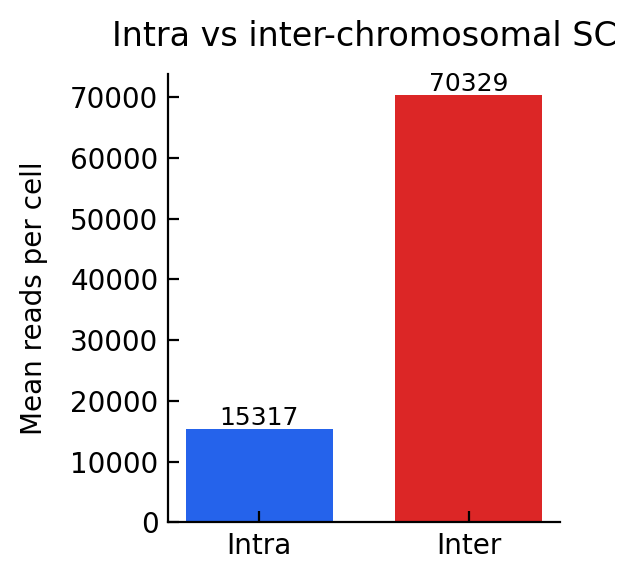

In [9]:
per_cell = (
    var_df.groupby("basename")["is_inter"]
    .agg(n_inter="sum", n_total="count")
    .assign(n_intra=lambda d: d["n_total"] - d["n_inter"])
)
mean_intra = per_cell["n_intra"].mean()
mean_inter = per_cell["n_inter"].mean()

fig, ax = plt.subplots(figsize=(3, 3))
counts = [mean_intra, mean_inter]
labels = ["Intra", "Inter"]
colors = ["#2563eb", "#dc2626"]
ax.bar(labels, counts, color=colors, edgecolor="none", width=0.7)
ax.set_ylabel("Mean reads per cell", labelpad=8)
ax.set_title("Intra vs inter-chromosomal SC", pad=10, loc="center")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)
for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

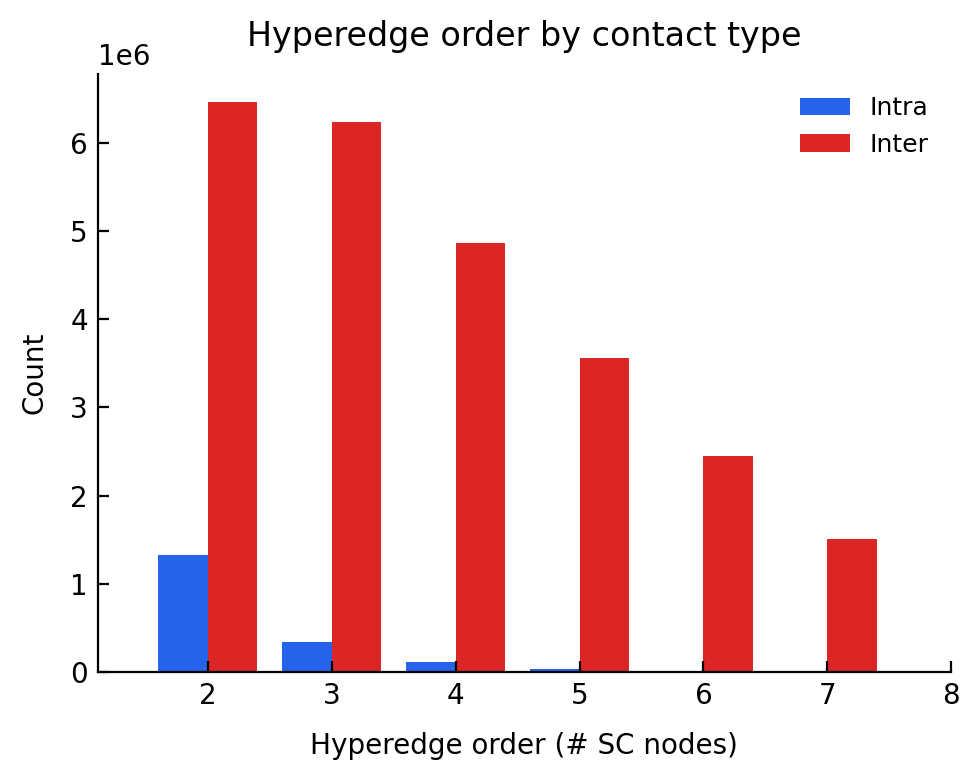

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
bins  = np.arange(2, 12)
intra = var_df[~var_df["is_inter"]]["n_nodes"].values
inter = var_df[ var_df["is_inter"]]["n_nodes"].values
width = 0.4
intra_counts = np.array([(intra == b).sum() for b in bins])
inter_counts = np.array([(inter == b).sum() for b in bins])
ax.bar(bins - width/2, intra_counts, width=width, color="#2563eb", label="Intra", edgecolor="none")
ax.bar(bins + width/2, inter_counts, width=width, color="#dc2626", label="Inter", edgecolor="none")
ax.set_xlabel("Hyperedge order (# SC nodes)", labelpad=8)
ax.set_ylabel("Count", labelpad=8)
ax.set_title("Hyperedge order by contact type", pad=10, loc="center")
ax.set_xlim(right=8)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(direction="in", length=4, width=0.8)
plt.tight_layout()
plt.show()

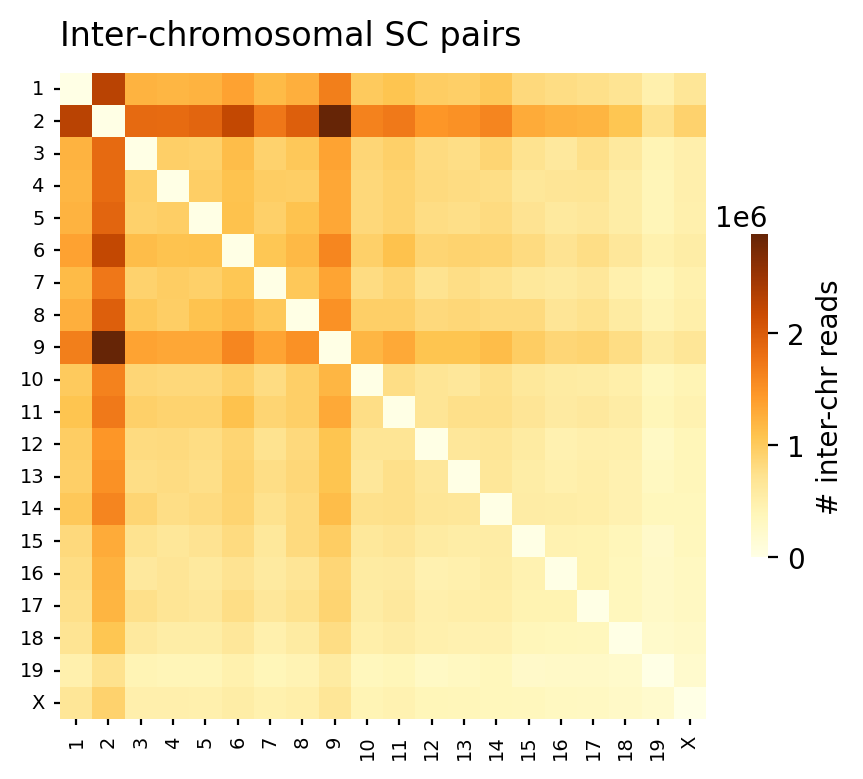

In [11]:
inter_read_mask = var_df["is_inter"].values                  # bool (n_reads,)
inter_presence  = chrom_presence[:, inter_read_mask]         # (n_chroms × n_inter_reads)

# For each pair (i,j), count reads where both chroms are present
mat_sc = np.zeros((n_chr, n_chr))
for i in range(n_chr):
    for j in range(i+1, n_chr):
        cnt = int((inter_presence[i] & inter_presence[j]).sum())
        mat_sc[i, j] = cnt
        mat_sc[j, i] = cnt

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    mat_sc,
    cmap="YlOrBr",
    square=True,
    xticklabels=all_chroms_sc,
    yticklabels=all_chroms_sc,
    linewidths=0,
    cbar_kws={"shrink": 0.5, "label": "# inter-chr reads"},
    ax=ax,
)
ax.set_title("Inter-chromosomal SC pairs", pad=10, loc="left")
ax.tick_params(labelsize=7, length=2)
plt.tight_layout()
plt.show()

In [ ]:
CN     = pd.read_csv("centrality_core/core_nodes.csv")
CE     = pd.read_csv("centrality_core/core_edges.csv")
H_core = sp.load_npz("centrality_core/H_core.npz")   # rows = CN, cols = CE

print(f"CN: {len(CN)} core nodes")
print(f"CE: {len(CE)} core edges")
print(f"H_core: {H_core.shape}")
print(f"\nCN columns:  {CN.columns.tolist()}")
print(f"CE columns:  {CE.columns.tolist()}")

In [ ]:
def parse_genes(series):
    """Flatten a column of comma/semicolon-separated gene strings into a set."""
    genes = set()
    for val in series.dropna():
        for g in str(val).replace(";", ",").split(","):
            g = g.strip()
            if g and g != "nan":
                genes.add(g)
    return genes

# Genes overlapping core nodes (loci)
#cn_genes = parse_genes(CN["genes"])

# Genes overlapping core edges (reads) — usually richer
ce_genes = parse_genes(CE["genes"])

# Union
#all_core_genes = cn_genes | ce_genes
all_core_genes = ce_genes

#print(f"Genes in CN loci:       {len(cn_genes)}")
print(f"Genes in CE hyperedges: {len(ce_genes)}")
print(f"Union:                  {len(all_core_genes)}")

In [ ]:
# Map each CN row index to its chromosome
cn_chrom = CN["chrom"].values   # length = H_core.shape[0]

H_csc = H_core.tocsc()

edge_stats = []
for j in range(H_csc.shape[1]):
    col     = H_csc[:, j]
    members = col.nonzero()[0]           # CN row indices in this hyperedge
    chroms  = set(cn_chrom[members])
    edge_stats.append({
        "edge_idx":    j,
        "n_nodes":     len(members),
        "n_chroms":    len(chroms),
        "chroms":      ",".join(sorted(chroms)),
        "is_inter":    len(chroms) > 1,
    })

edge_df = pd.DataFrame(edge_stats)

n_intra = (~edge_df["is_inter"]).sum()
n_inter = edge_df["is_inter"].sum()
print(f"Intra-chromosomal CE: {n_intra} ({100*n_intra/len(edge_df):.1f}%)")
print(f"Inter-chromosomal CE: {n_inter} ({100*n_inter/len(edge_df):.1f}%)")